# Classification Model to Identify Multiple Disease

## Import Library

In [1]:
#Step 1: Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import and read data

In [2]:
#Step 2: import data
df= pd.read_csv('https://github.com/ybifoundation/Dataset/raw/main/MultipleDiseasePrediction.csv')

## Study DataSet

In [3]:
#Step 3.1: View data(The head() method returns a specified number of rows, string from the top.)
df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [4]:
#Step 3.2: Info of data(The info() method prints information about the DataFrame).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


In [5]:
# step 3.3: Summary Statistics(The describe() method returns description of the data in the DataFrame.)
df.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
#Step 3.4: Checking for Missing Values
df.isnull().sum()

,0
itching,0
skin_rash,0
nodal_skin_eruptions,0
continuous_sneezing,0
shivering,0
...,...
inflammatory_nails,0
blister,0
red_sore_around_nose,0
yellow_crust_ooze,0


In [7]:
#Step 3.5: Check for Categories
df.value_counts()

itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  muscle_wasting  vomiting  burning_micturition  spotting_ urination  fatigue  weight_gain  anxiety  cold_hands_and_feets  mood_swings  weight_loss  restlessness  lethargy  patches_in_throat  irregular_sugar_level  cough  high_fever  sunken_eyes  breathlessness  sweating  dehydration  indigestion  headache  yellowish_skin  dark_urine  nausea  loss_of_appetite  pain_behind_the_eyes  back_pain  constipation  abdominal_pain  diarrhoea  mild_fever  yellow_urine  yellowing_of_eyes  acute_liver_failure  fluid_overload  swelling_of_stomach  swelled_lymph_nodes  malaise  blurred_and_distorted_vision  phlegm  throat_irritation  redness_of_eyes  sinus_pressure  runny_nose  congestion  chest_pain  weakness_in_limbs  fast_heart_rate  pain_during_bowel_movements  pain_in_anal_region  bloody_stool  irritation_in_anus  neck_pain  dizziness  cramps  bruising  obesity  swollen_legs  swollen_blood_vessels  puffy_face_and_eyes  enlarged_thyroid  brittle_nails  swollen_extremeties  excessive_hunger  extra_marital_contacts  drying_and_tingling_lips  slurred_speech  knee_pain  hip_joint_pain  muscle_weakness  stiff_neck  swelling_joints  movement_stiffness  spinning_movements  loss_of_balance  unsteadiness  weakness_of_one_body_side  loss_of_smell  bladder_discomfort  foul_smell_of urine  continuous_feel_of_urine  passage_of_gases  internal_itching  toxic_look_(typhos)  depression  irritability  muscle_pain  altered_sensorium  red_spots_over_body  belly_pain  abnormal_menstruation  dischromic _patches  watering_from_eyes  increased_appetite  polyuria  family_history  mucoid_sputum  rusty_sputum  lack_of_concentration  visual_disturbances  receiving_blood_transfusion  receiving_unsterile_injections  coma  stomach_bleeding  distention_of_abdomen  history_of_alcohol_consumption  fluid_overload.1  blood_in_sputum  prominent_veins_on_calf  palpitations  painful_walking  pus_filled_pimples  blackheads  scurring  skin_peeling  silver_like_dusting  small_dents_in_nails  inflammatory_nails  blister  red_sore_around_nose  yellow_crust_ooze  prognosis                   
0        0          0                     0                    0          0       0           0             0        0                 0               0         0                    0                    0        0            0        0                     0            0            0             0         0                  0                      0      0           0            0               0         0            0            0         0               0           0       0                 0                     0          0             0               0          0           0             0                  0                    0               0                    0                    0        0                             0       0                  0                0               0           0           0           0                  0                0                            0                    0             0                   0          0          0       0         0        0             0                      0                    0                 0              0                    0                 0                       0                         0               0          0               1                1           1                1                   0                   0                0             0                          0              0                   0                    0                         0                 0                 0                    0           0             0            0                  0                    0           0                      0                    0                   0                   0         0               0              0             0                      0                    0              

In [8]:
# Step 3.6: DataType
df.dtypes

,0
itching,int64
skin_rash,int64
nodal_skin_eruptions,int64
continuous_sneezing,int64
shivering,int64
...,...
inflammatory_nails,int64
blister,int64
red_sore_around_nose,int64
yellow_crust_ooze,int64


In [9]:
#Step 3.7: Correlation(The corr() method calculates the relationship between each column in the data set.)
df.corr(numeric_only=True)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
itching,1.000000,0.318158,0.326439,-0.086906,-0.059893,-0.175905,-0.160650,0.202850,-0.086906,-0.059893,...,-0.059893,-0.059893,-0.059893,-0.061573,-0.061573,-0.061573,-0.061573,-0.061573,-0.061573,-0.061573
skin_rash,0.318158,1.000000,0.298143,-0.094786,-0.065324,-0.029324,0.171134,0.161784,-0.094786,-0.065324,...,0.320859,0.320859,0.320859,0.331087,0.331087,0.331087,0.331087,0.331087,0.331087,0.331087
nodal_skin_eruptions,0.326439,0.298143,1.000000,-0.032566,-0.022444,-0.065917,-0.060200,-0.032566,-0.032566,-0.022444,...,-0.022444,-0.022444,-0.022444,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073
continuous_sneezing,-0.086906,-0.094786,-0.032566,1.000000,0.608981,0.446238,-0.087351,-0.047254,-0.047254,-0.032566,...,-0.032566,-0.032566,-0.032566,-0.033480,-0.033480,-0.033480,-0.033480,-0.033480,-0.033480,-0.033480
shivering,-0.059893,-0.065324,-0.022444,0.608981,1.000000,0.295332,-0.060200,-0.032566,-0.032566,-0.022444,...,-0.022444,-0.022444,-0.022444,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
small_dents_in_nails,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,0.359845,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,-0.023073,0.946120,0.946120,1.000000,0.946120,-0.023720,-0.023720,-0.023720
inflammatory_nails,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,0.359845,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,-0.023073,0.946120,0.946120,0.946120,1.000000,-0.023720,-0.023720,-0.023720
blister,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,-0.061889,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,-0.023073,-0.023720,-0.023720,-0.023720,-0.023720,1.000000,0.946120,0.946120
red_sore_around_nose,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,-0.061889,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,-0.023073,-0.023720,-0.023720,-0.023720,-0.023720,0.946120,1.000000,0.946120


## Pair Plot

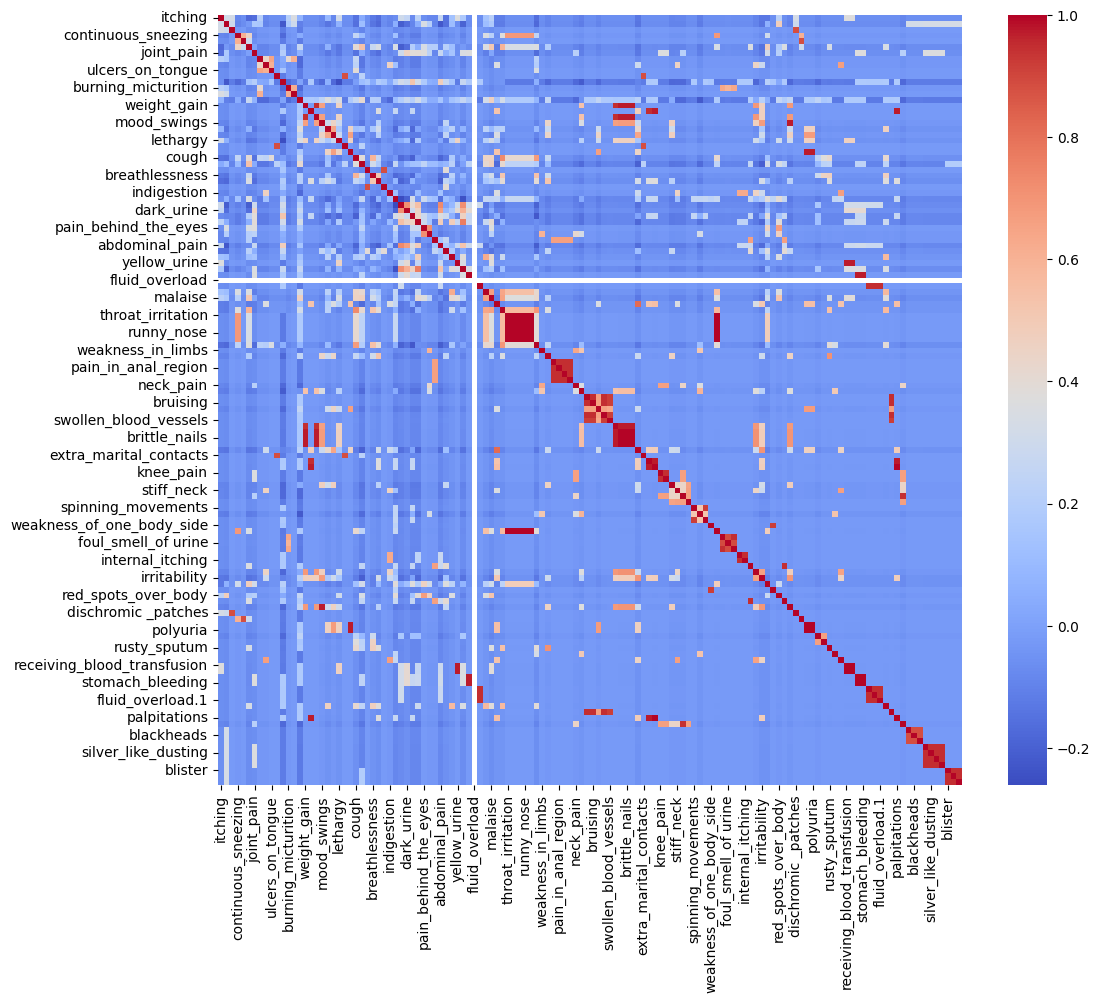

In [10]:

# visualize pairplot
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()


## Get Columns Name

In [11]:
#Return the column labels of the DataFrame:
df.columns

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'blackheads', 'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis'],
      dtype='object', length=133)

## Define Y [Target/Dependent variable] & X [Features/Independent variable]

In [12]:
#Step 4.1: Define 'Y'
y =df['prognosis']

In [13]:
#Shape: The shape is the number of rows and columns of the DataFrame
y.shape

(4920,)

In [14]:
y

,prognosis
0,Fungal infection
1,Fungal infection
2,Fungal infection
3,Fungal infection
4,Fungal infection
...,...
4915,(vertigo) Paroymsal Positional Vertigo
4916,Acne
4917,Urinary tract infection
4918,Psoriasis


In [15]:
#Step 4.2: Define 'X'
X=df.drop(['prognosis'], axis=1)

In [16]:
X

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4916,0,1,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4918,0,1,0,0,0,0,1,0,0,0,...,0,0,0,1,1,1,1,0,0,0


## Splitting the data

In [17]:
#Step 5 : Split data into Train & Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=2529)


In [18]:
#Verify Shape
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((3690, 132), (1230, 132), (3690,), (1230,))

## Selecting the model

In [19]:
#Step 6.1: select model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [20]:
#Step 6.2: train model
model.fit(X_train,y_train)

RandomForestClassifier()

## Predicting Model

In [21]:
#Step 7: predict with model
y_pred=model.predict(X_test)


In [22]:
y_pred.shape

(1230,)

In [23]:
y_pred

array(['Osteoarthristis', 'Allergy', 'Tuberculosis', ...,
       'Fungal infection', 'Hepatitis D', 'Acne'], dtype=object)

## Error Caluclation

In [24]:
#Step 8: model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [25]:
# model accuracy
accuracy_score(y_test,y_pred)

1.0

In [26]:
# model confusion matrix
confusion_matrix(y_test,y_pred)

array([[26,  0,  0, ...,  0,  0,  0],
       [ 0, 28,  0, ...,  0,  0,  0],
       [ 0,  0, 31, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 30,  0,  0],
       [ 0,  0,  0, ...,  0, 26,  0],
       [ 0,  0,  0, ...,  0,  0, 30]])

In [27]:
# model classification report
print(classification_report(y_test,y_pred))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        26
                                   AIDS       1.00      1.00      1.00        28
                                   Acne       1.00      1.00      1.00        31
                    Alcoholic hepatitis       1.00      1.00      1.00        36
                                Allergy       1.00      1.00      1.00        28
                              Arthritis       1.00      1.00      1.00        36
                       Bronchial Asthma       1.00      1.00      1.00        32
                   Cervical spondylosis       1.00      1.00      1.00        26
                            Chicken pox       1.00      1.00      1.00        26
                    Chronic cholestasis       1.00      1.00      1.00        28
                            Common Cold       1.00      1.00      1.00        36
                           

## Future prediction

In [28]:
# future prediction
sample=df.sample()
sample

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
2316,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Common Cold


In [29]:
# define X_new
X_new = X.sample()
X_new.sample()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
1000,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# predict for X_new
model.predict(X_new)


array(['Typhoid'], dtype=object)